# 1D Kalman Filter with Delayed and Out-of-Order Measurements

This notebook demonstrates a simple 1D Kalman filter that can handle:

- normal in-order measurements,
- delayed measurements,
- out-of-order measurements,
- rollback and replay using a measurement history.

The state is:

$$
x = \begin{bmatrix} position \\ velocity \end{bmatrix}
$$

The measurement observes only position:

$$
z = position + noise
$$


## Main idea

While no measurement has arrived, the filter keeps predicting forward using the motion model.

When a delayed measurement arrives, we should **not** apply it directly to the current state. Instead:

1. go back to the state at the measurement timestamp,
2. apply the Kalman update there,
3. replay all later predictions and measurements up to the current time.

This is called **rollback and replay**.


In [1]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt


## Data structures

`Measurement` stores a timestamped position measurement.

`Snapshot` stores the filter state at a specific time, so that we can replay the filter if needed.


In [2]:
@dataclass
class Measurement:
    time: float
    y: float
    R: float


@dataclass
class Snapshot:
    time: float
    x: np.ndarray
    P: np.ndarray
    kind: str = "snapshot"
    arrival_index: int = 0


## Kalman filter implementation

This implementation is intentionally simple. Whenever a delayed or out-of-order measurement arrives, it replays the full measurement history from the beginning.

That is not the most efficient approach, but it is easy to understand and correct for small examples.


In [3]:
class DelayedKalman1D:
    def __init__(self, x0, P0, process_accel_std=0.5):
        """
        State:
            x[0] = position
            x[1] = velocity
        """
        self.x = np.array(x0, dtype=float).reshape(2, 1)
        self.P = np.array(P0, dtype=float)

        self.q = process_accel_std ** 2
        self.current_time = 0.0
        self.arrival_index = 0

        # Keep initial state separately so replay is clean.
        self.initial_snapshot = Snapshot(
            self.current_time,
            self.x.copy(),
            self.P.copy(),
            kind="initial",
            arrival_index=self.arrival_index
        )

        # History of filter snapshots after each event.
        self.history = [self.initial_snapshot]

        # Everything the online filter ever produced in real arrival order.
        # This is not rewritten during replay.
        self.timeline_log = [self.initial_snapshot]
        
        # Store all accepted measurements so we can replay them.
        self.measurements = []

    def F(self, dt):
        return np.array([
            [1.0, dt],
            [0.0, 1.0]
        ])

    def Q(self, dt):
        """
        Constant-velocity model with white acceleration noise.
        """
        return self.q * np.array([
            [dt**4 / 4.0, dt**3 / 2.0],
            [dt**3 / 2.0, dt**2]
        ])

    def H(self):
        return np.array([[1.0, 0.0]])

    def predict_to(self, target_time):
        dt = target_time - self.current_time

        if dt < -1e-9:
            raise ValueError(
                f"Cannot predict backwards: current_time={self.current_time}, "
                f"target_time={target_time}"
            )

        if abs(dt) < 1e-12:
            return

        F = self.F(dt)
        Q = self.Q(dt)

        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q
        self.current_time = target_time

    def measurement_update(self, y, R):
        H = self.H()
        y = np.array([[y]])

        e = y - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ e
        self.P = (np.eye(2) - K @ H) @ self.P

    def make_snapshot(self, kind):
        return Snapshot(
            self.current_time,
            self.x.copy(),
            self.P.copy(),
            kind=kind,
            arrival_index=self.arrival_index
        )
        
    def save_history_snapshot(self, kind):
        self.history.append(self.make_snapshot(kind))

    def save_timeline_snapshot(self, kind):
        self.timeline_log.append(self.make_snapshot(kind))

    def process_in_order_measurement(self, measurement, log_to_timeline=True):
        """
        Normal case: measurement timestamp is >= current filter time.
        """
        self.predict_to(measurement.time)
        if log_to_timeline:
            self.save_timeline_snapshot("prediction_before_update")
        self.measurement_update(measurement.y, measurement.R)
        self.save_history_snapshot("measurement_update")
        if log_to_timeline:
            self.save_timeline_snapshot("measurement_update")

    def process_measurement(self, measurement):
        """
        Handles both in-order and delayed/out-of-order measurements.
        """
        self.arrival_index += 1
        self.measurements.append(measurement)
        self.measurements.sort(key=lambda m: m.time)

        if measurement.time >= self.current_time:
            # Easy case: measurement is in chronological order.
            self.process_in_order_measurement(measurement, log_to_timeline=True)
        else:
            # Delayed or out-of-order measurement.
            target_time = self.current_time
            self.rollback_and_replay(target_time=target_time)
            self.save_timeline_snapshot("corrected_after_replay")

    def rollback_and_replay(self, target_time=None):
        if target_time is None:
            target_time = self.current_time

        initial = self.initial_snapshot

        self.x = initial.x.copy()
        self.P = initial.P.copy()
        self.current_time = initial.time

        # Rebuild only the corrected history.
        # Do not erase timeline_log, because timeline_log is the live evolution.
        self.history = [
            Snapshot(
                self.current_time,
                self.x.copy(),
                self.P.copy(),
                kind="initial",
                arrival_index=self.arrival_index
            )
        ]

        for m in self.measurements:
            if m.time <= target_time + 1e-9:
                self.process_in_order_measurement(
                    m,
                    log_to_timeline=False
                )

        if self.current_time < target_time:
            self.predict_to(target_time)
            self.save_history_snapshot("prediction_after_replay")

    def predict_without_measurement(self, target_time):
        self.arrival_index += 1

        self.predict_to(target_time)

        snapshot = self.make_snapshot("prediction_only")
        self.history.append(snapshot)
        self.timeline_log.append(snapshot)

    def state(self):
        return {
            "time": self.current_time,
            "position": float(self.x[0, 0]),
            "velocity": float(self.x[1, 0]),
            "P": self.P.copy()
        }


## Helper function for printing filter state


In [4]:
def print_state(label, kf):
    s = kf.state()
    print(label)
    print(f"  time     = {s['time']:.2f}")
    print(f"  position = {s['position']:.3f}")
    print(f"  velocity = {s['velocity']:.3f}")
    print(f"  P =\n{s['P']}")
    print()


## Example: prediction, normal measurement, delayed measurement

Here we simulate a filter that first predicts forward without measurements.

Then a normal measurement arrives at `t = 2.0`.

Later, after the filter has already reached `t = 3.0`, a delayed measurement from `t = 1.5` arrives.


In [5]:
kf = DelayedKalman1D(
    x0=[0.0, 1.0],
    P0=[[1.0, 0.0],
        [0.0, 1.0]],
    process_accel_std=0.2
)

print_state("Initial state", kf)

# Time moves forward. No measurement yet.
kf.predict_without_measurement(1.0)
print_state("After prediction to t=1", kf)

# Another prediction. Still no measurement.
kf.predict_without_measurement(2.0)
print_state("After prediction to t=2", kf)

# Measurement at t=2 arrives normally.
m = Measurement(time=2.0, y=2.2, R=0.1)
kf.process_measurement(m)
print_state(f"After measurement y={m.y} at t={m.time}", kf)

# Time moves forward again.
kf.predict_without_measurement(3.0)
print_state("After prediction to t=3", kf)

# A delayed measurement arrives.
# It was taken at t=1.5, but it arrives after we are already at t=3.
m = Measurement(time=1.5, y=1.4, R=0.1)
kf.process_measurement(m)
print_state(f"After delayed measurement y={m.y} from t={m.time}", kf)

# Another out-of-order measurement, older than the current filter time.
m = Measurement(time=2.5, y=2.6, R=0.1)
kf.process_measurement(m)
print_state(f"After delayed measurement y={m.y} from t={m.time}", kf)


Initial state
  time     = 0.00
  position = 0.000
  velocity = 1.000
  P =
[[1. 0.]
 [0. 1.]]

After prediction to t=1
  time     = 1.00
  position = 1.000
  velocity = 1.000
  P =
[[2.01 1.02]
 [1.02 1.04]]

After prediction to t=2
  time     = 2.00
  position = 2.000
  velocity = 1.000
  P =
[[5.1  2.08]
 [2.08 1.08]]

After measurement y=2.2 at t=2.0
  time     = 2.00
  position = 2.196
  velocity = 1.080
  P =
[[0.09807692 0.04      ]
 [0.04       0.248     ]]

After prediction to t=3
  time     = 3.00
  position = 3.276
  velocity = 1.080
  P =
[[0.43607692 0.308     ]
 [0.308      0.288     ]]

After delayed measurement y=1.4 from t=1.5
  time     = 3.00
  position = 3.280
  velocity = 1.175
  P =
[[0.43529825 0.30587307]
 [0.30587307 0.25665461]]

After delayed measurement y=2.6 from t=2.5
  time     = 3.00
  position = 3.191
  velocity = 1.119
  P =
[[0.15695032 0.12193286]
 [0.12193286 0.12647462]]



## Visualize filter history

The history stores snapshots after predictions and updates. The plot below shows the estimated position after the replay has incorporated all received measurements.


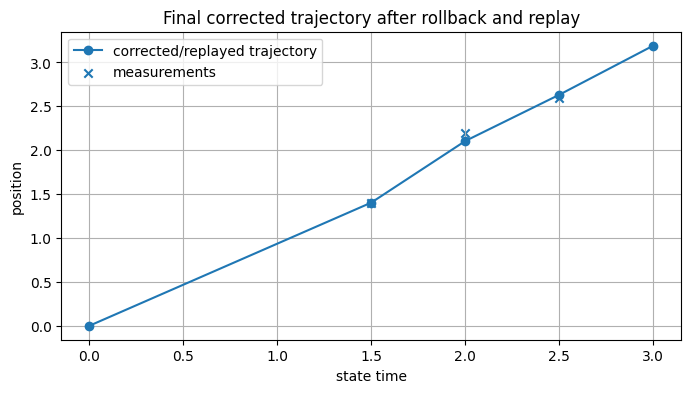

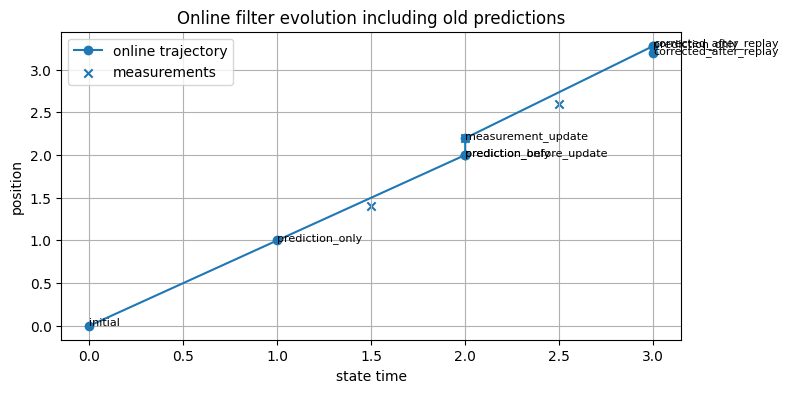

In [6]:
history_times = [s.time for s in kf.history]
history_positions = [float(s.x[0, 0]) for s in kf.history]
plt.figure(figsize=(8, 4))
plt.plot(history_times, history_positions, marker="o", label="corrected/replayed trajectory")
plt.scatter(
    [m.time for m in kf.measurements],
    [m.y for m in kf.measurements],
    marker="x",
    label="measurements"
)
plt.xlabel("state time")
plt.ylabel("position")
plt.title("Final corrected trajectory after rollback and replay")
plt.grid(True)
plt.legend()
plt.show()

# evolution including obsolete predictions
timeline_times = [s.time for s in kf.timeline_log]
timeline_positions = [float(s.x[0, 0]) for s in kf.timeline_log]
timeline_labels = [s.kind for s in kf.timeline_log]
plt.figure(figsize=(8, 4))
plt.plot(timeline_times, timeline_positions, marker="o", label="online trajectory")
for t, p, label in zip(timeline_times, timeline_positions, timeline_labels):
    plt.text(t, p, label, fontsize=8)
plt.scatter(
    [m.time for m in kf.measurements],
    [m.y for m in kf.measurements],
    marker="x",
    label="measurements"
)
plt.xlabel("state time")
plt.ylabel("position")
plt.title("Online filter evolution including old predictions")
plt.grid(True)
plt.legend()
plt.show()


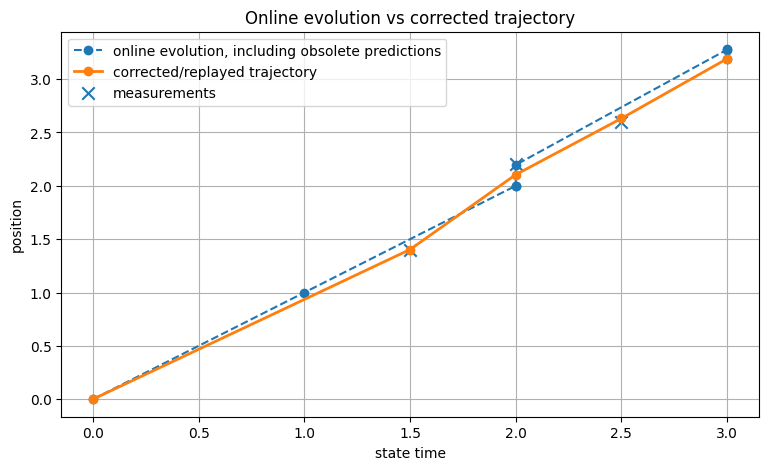

In [7]:
# additional comparison plot
# superpose corrected/replayed trajectory and online evolution
history_times = [s.time for s in kf.history]
history_positions = [float(s.x[0, 0]) for s in kf.history]
timeline_times = [s.time for s in kf.timeline_log]
timeline_positions = [float(s.x[0, 0]) for s in kf.timeline_log]
measurement_times = [m.time for m in kf.measurements]
measurement_values = [m.y for m in kf.measurements]

plt.figure(figsize=(9, 5))
plt.plot(
    timeline_times,
    timeline_positions,
    marker="o",
    linestyle="--",
    label="online evolution, including obsolete predictions"
)
plt.plot(
    history_times,
    history_positions,
    marker="o",
    linewidth=2,
    label="corrected/replayed trajectory"
)
plt.scatter(
    measurement_times,
    measurement_values,
    marker="x",
    s=80,
    label="measurements"
)
plt.xlabel("state time")
plt.ylabel("position")
plt.title("Online evolution vs corrected trajectory")
plt.grid(True)
plt.legend()
plt.show()

## What do we do while waiting for measurements?

We keep predicting:

$$
\hat{x}_k = F \hat{x}_{k-1}
$$

$$
P_k = F P_{k-1} F^T + Q
$$

So the filter estimate continues to move according to the model, but the uncertainty grows.

When the delayed measurement arrives, the filter corrects the old state and replays forward.


## Practical note

In real systems, always distinguish between:

- **measurement time**: when the sensor took the measurement,
- **arrival time**: when your software received the message.

The Kalman filter update should use the measurement time, not the arrival time.

One additonal thing to keep in mind is **how to deal with the input**: in case there are input events, also these needs to be stored and replayed in order to get the correct estimated state. In the above implementation this is not considered.
